# demo of my micrograd

In [1]:
from utils import draw_graph
from micrograd.engine import Value
from micrograd.nn import MLP
import torch
import matplotlib.pyplot as plt

## visualize the Value class operations

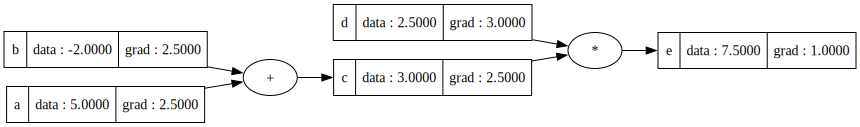

In [2]:
# c = a + b
# e = d * c 

a = Value(5.0, label='a')
b = Value(-2.0, label='b')

c = a + b; c.label = 'c'

d = Value(2.5, label='d')

e = d * c; e.label='e'

#backward
e.backward()

draw_graph(e)


## Pytorch vs micrograd
Let's build a simple mathematical expression: $g = (a \times b) + c$ and evaluate its gradients using our custom `Value` engine versus industry-standard **PyTorch**.

In [3]:
# 1. Micrograd calculation
a = Value(-4.0)
b = Value(2.0)
c = Value(5.0)
g = a * b + c
g.backward()
mg_da, mg_db, mg_dc = a.grad, b.grad, c.grad

# 2. PyTorch calculation
a_pt = torch.tensor([-4.0], requires_grad=True)
b_pt = torch.tensor([2.0], requires_grad=True)
c_pt = torch.tensor([5.0], requires_grad=True)
g_pt = a_pt * b_pt + c_pt
g_pt.backward()
pt_da, pt_db, pt_dc = a_pt.grad.item(), b_pt.grad.item(), c_pt.grad.item()

# 3. Assert exact equality
print(f"Micrograd Gradients -> da: {mg_da}, db: {mg_db}, dc: {mg_dc}")
print(f"PyTorch Gradients   -> da: {pt_da}, db: {pt_db}, dc: {pt_dc}")

assert mg_da == pt_da, "Gradient mismatch for 'a'!"
assert mg_db == pt_db, "Gradient mismatch for 'b'!"
assert mg_dc == pt_dc, "Gradient mismatch for 'c'!"
print("\n🎉 Sanity Check Passed! Gradients match PyTorch exactly.")

Micrograd Gradients -> da: 2.0, db: -4.0, dc: 1.0
PyTorch Gradients   -> da: 2.0, db: -4.0, dc: 1.0

🎉 Sanity Check Passed! Gradients match PyTorch exactly.


##  Building a Toy Dataset
We will create a small binary classification dataset. Let's cook up 4 distinct points representing a simple nonlinear function, along with their ground-truth labels ($y = 1$ or $y = -1$).

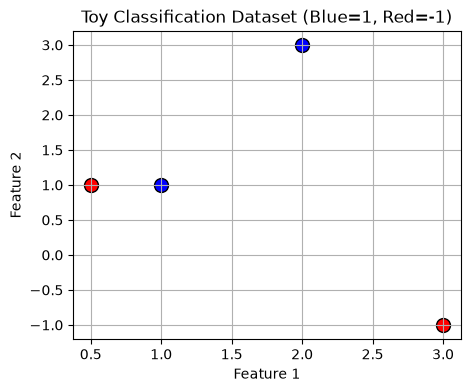

In [4]:
# Simple 2D coordinates inputs (4 samples, 2 features each)
X = [
    [2.0, 3.0],
    [3.0, -1.0],
    [0.5, 1.0],
    [1.0, 1.0]
]
# Desired target outputs
y = [1.0, -1.0, -1.0, 1.0] 

# Visualize the dataset points
plt.figure(figsize=(5,4))
for xi, yi in zip(X, y):
    color = 'blue' if yi == 1.0 else 'red'
    plt.scatter(xi[0], xi[1], c=color, s=100, edgecolors='k')
plt.title("Toy Classification Dataset (Blue=1, Red=-1)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

##  Initializing the Multi-Layer Perceptron (MLP)
We construct an MLP with 2 input features, two hidden layers containing 4 neurons each, and 1 final output scalar neuron layout: `MLP(2, [4, 4, 1])`.

In [5]:
# Instantiate model
model = MLP(2, [4, 4, 1])

print(f"Total number of parameters (weights + biases): {len(model.parameters())}")

Total number of parameters (weights + biases): 37


##  The Optimization Training Loop
We will run gradient descent optimization over 100 iterations (epochs) using a Mean Squared Error (MSE) loss function function. Watch the total loss decrease!

In [6]:
learning_rate = 0.05

print("Starting training loop...")
print("-" * 30)

for epoch in range(101):
    
    # 1. Forward Pass: compute predictions for all inputs
    ypred = [model(x) for x in X]
    
    # 2. Compute Loss (Mean Squared Error)
    loss = sum((yout[0] - ygt)**2 for ygt, yout in zip(y, ypred))
    
    # 3. Reset Gradients (Zero Grad)
    model.zero_grad()
    
    # 4. Backward Pass (Backpropagation)
    loss.backward()
    
    # 5. Stochastic Gradient Descent Update (SGD step)
    for p in model.parameters():
        p.data -= learning_rate * p.grad
        
    # Print status updates every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.data:.4f}")

print("-" * 30)
print("Final Trained Predictions vs Targets:")
for ygt, prediction in zip(y, ypred):
    print(f"Target: {ygt:4.1f} | Predicted: {prediction[0].data:7.4f}")

Starting training loop...
------------------------------
Epoch   0 | Loss: 2.8317
Epoch  10 | Loss: 1.3886
Epoch  20 | Loss: 0.7861
Epoch  30 | Loss: 0.6504
Epoch  40 | Loss: 0.0938
Epoch  50 | Loss: 0.0628
Epoch  60 | Loss: 0.0461
Epoch  70 | Loss: 0.0359
Epoch  80 | Loss: 0.0291
Epoch  90 | Loss: 0.0244
Epoch 100 | Loss: 0.0208
------------------------------
Final Trained Predictions vs Targets:
Target:  1.0 | Predicted:  0.9822
Target: -1.0 | Predicted: -0.9473
Target: -1.0 | Predicted: -0.9088
Target:  1.0 | Predicted:  0.9030
